# 31 — Circuit-Theory Current Flow for Threatened Species

Compute circuit-theory connectivity for all threatened species that have
GNN-SDM suitability scores. This notebook produces the **raw current flow**
per species; normalisation and aggregation decisions are deferred to
notebook 32 (gap analysis).

**Steps**:
1. Load the 23 threatened species identified in notebook 00b
2. For each species, compute current flow between observed population clusters
3. Inspect per-species current distributions (histograms)
4. Save raw current arrays + suitability to `.npz` for notebook 32

### Setup

In [1]:
import config
import numpy as np
import pandas as pd
import pickle
import time
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from data_utils import load_species_patches, load_patch_data

with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

patch_features, patch_counts, feature_names = load_patch_data()
n_patches = G.number_of_nodes()
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges')

species_patches, species_counts = load_species_patches(config)

# Load GNN suitability scores
scores_npz = np.load('gnn_training_output/suitability_scores.npz')
def get_suitability(sp):
    key = sp.replace(' ', '_')
    return scores_npz[key] if key in scores_npz.files else None

print(f'Suitability scores for {len(scores_npz.files):,} species')

Patches: 166,464, features: 12
Graph: 166,464 nodes, 465,833 edges
GBIF records: 22,723,973
Species with >= 100 records: 3,756
Suitability scores for 3,751 species


### Load threatened species list from notebook 00b

We exclude non-native/planted species whose IUCN status refers to their
native range, not their conservation need in Switzerland (e.g. *Ginkgo*,
*Sequoia*, *Cedrus*, ornamental conifers). We also require that the
circuit-theory solver finds ≥2 connected components of observation
patches — otherwise there is no connectivity to measure.

In [2]:
# Load threat status CSV produced by notebook 00b
status_df = pd.read_csv('species_threat_status.csv')

# Filter to threatened species (NT + VU + EN + CR) that have GNN scores
THREAT_CATEGORIES = ['CRITICALLY_ENDANGERED', 'ENDANGERED', 'VULNERABLE', 'NEAR_THREATENED']
threatened_df = status_df[
    (status_df['iucn_category'].isin(THREAT_CATEGORIES))
    & (status_df['has_gnn_scores'] == True)
].copy()

# Exclude non-native/planted species whose IUCN status refers to their
# native range outside Switzerland (parks, gardens, arboreta)
NON_NATIVE = [
    'Ginkgo biloba',             # native to China
    'Sequoiadendron giganteum',   # native to California
    'Sequoia sempervirens',       # native to California
    'Cedrus atlantica',           # native to North Africa
    'Platycladus orientalis',     # native to East Asia
    'Chamaecyparis lawsoniana',   # native to North America
    'Pterocarya fraxinifolia',    # native to Caucasus
    'Aesculus hippocastanum',     # native to Balkans, widely planted
]
threatened_df = threatened_df[~threatened_df['species'].isin(NON_NATIVE)]

THREATENED = threatened_df['species'].tolist()
print(f'Threatened native species with GNN scores: {len(THREATENED)}')
print(f'  (excluded {len(NON_NATIVE)} non-native species)')
print(f'  CR: {(threatened_df["iucn_category"] == "CRITICALLY_ENDANGERED").sum()}')
print(f'  EN: {(threatened_df["iucn_category"] == "ENDANGERED").sum()}')
print(f'  VU: {(threatened_df["iucn_category"] == "VULNERABLE").sum()}')
print(f'  NT: {(threatened_df["iucn_category"] == "NEAR_THREATENED").sum()}')
print()
for sp in THREATENED:
    presence = species_patches.get(sp, set())
    print(f'  {sp}: {len(presence)} patches')

Threatened native species with GNN scores: 15
  (excluded 8 non-native species)
  CR: 0
  EN: 2
  VU: 3
  NT: 10

  Aldrovanda vesiculosa: 26 patches
  Andreaea frigida: 48 patches
  Baldellia ranunculoides: 76 patches
  Eryngium alpinum: 1045 patches
  Fraxinus excelsior: 8674 patches
  Frullania jackii: 69 patches
  Galanthus nivalis: 1910 patches
  Gentiana pannonica: 36 patches
  Jacobaea uniflora: 141 patches
  Poa laxa: 339 patches
  Poterium dodecandrum: 94 patches
  Pulsatilla vulgaris: 550 patches
  Riccia breidleri: 23 patches
  Trifolium saxatile: 69 patches
  Woodsia pulchella: 24 patches


### Circuit-theory current flow function

In [3]:
def compute_current_flow(G, suitability, core_patches, n_pairs=6, min_component_size=3):
    """
    Circuit-theory current flow between known population clusters.

    Parameters
    ----------
    G : nx.Graph
        Landscape patch graph.
    suitability : np.ndarray (n_patches,)
        Per-patch GNN suitability used as conductance.
    core_patches : set[int]
        Patch IDs where the species has been observed.
    n_pairs : int
        Number of source-ground component pairs to solve.
    min_component_size : int
        Minimum patches for a core component to be considered.

    Returns
    -------
    current : np.ndarray (n_patches,)
        Raw cumulative current flow through each patch.
    n_components : int
        Number of qualifying core components found.
    """
    n = G.number_of_nodes()
    nodes = sorted(G.nodes())
    node_to_idx = {nd: i for i, nd in enumerate(nodes)}

    # Build conductance Laplacian
    L = lil_matrix((n, n), dtype=np.float64)
    for u, v in G.edges():
        i, j = node_to_idx[u], node_to_idx[v]
        conductance = max(1e-4, (suitability[u] + suitability[v]) / 2)
        L[i, j] -= conductance
        L[j, i] -= conductance
        L[i, i] += conductance
        L[j, j] += conductance
    L = csr_matrix(L)

    # Core components from actual observations
    cores = set(core_patches)
    core_subgraph = G.subgraph(cores)
    components = [c for c in nx.connected_components(core_subgraph)
                  if len(c) >= min_component_size]
    components.sort(key=len, reverse=True)

    if len(components) < 2:
        return np.zeros(len(suitability)), len(components)

    # Solve current flow between top component pairs
    current = np.zeros(n, dtype=np.float64)
    n_solve = min(len(components), n_pairs)

    for pair_i in range(n_solve - 1):
        src_comp = components[pair_i]
        gnd_comp = components[pair_i + 1]

        rhs = np.zeros(n)
        src_idx = [node_to_idx[nd] for nd in src_comp]
        gnd_idx = [node_to_idx[nd] for nd in gnd_comp]
        for idx in src_idx:
            rhs[idx] = 1.0 / len(src_idx)
        for idx in gnd_idx:
            rhs[idx] = -1.0 / len(gnd_idx)

        pin = gnd_idx[0]
        L_solve = L.copy().tolil()
        L_solve[pin, :] = 0
        L_solve[pin, pin] = 1
        rhs[pin] = 0

        voltages = spsolve(csr_matrix(L_solve), rhs)

        node_current = np.zeros(n)
        for u, v in G.edges():
            i, j = node_to_idx[u], node_to_idx[v]
            cond = max(1e-4, (suitability[u] + suitability[v]) / 2)
            ec = abs(cond * (voltages[i] - voltages[j]))
            node_current[i] += ec
            node_current[j] += ec
        current += node_current

    # Map back to patch IDs
    result = np.zeros(len(suitability))
    for nd, idx in node_to_idx.items():
        result[nd] = current[idx]
    return result, len(components)

### Compute current flow for all threatened species

~30 s per species × 23 species ≈ ~12 min total.

In [4]:
results = {}  # species_name -> {'current': array, 'suitability': array, 'n_components': int, 'n_patches': int}

t0 = time.time()
skipped = []

for i, sp in enumerate(THREATENED):
    suit = get_suitability(sp)
    if suit is None:
        print(f'[{i+1}/{len(THREATENED)}] {sp} — NO SUITABILITY SCORES, skipping')
        skipped.append(sp)
        continue

    presence = species_patches.get(sp, set())
    if len(presence) < 10:
        print(f'[{i+1}/{len(THREATENED)}] {sp} — only {len(presence)} patches, skipping')
        skipped.append(sp)
        continue

    print(f'[{i+1}/{len(THREATENED)}] {sp} ({len(presence)} patches)...')
    current, n_comp = compute_current_flow(G, suit, presence, n_pairs=6)

    results[sp] = {
        'current': current,
        'suitability': suit,
        'n_components': n_comp,
        'n_patches': len(presence),
    }

    elapsed = time.time() - t0
    print(f'  Done ({elapsed:.0f}s elapsed, {n_comp} components, max_current={current.max():.4f})')

print(f'\nTotal time: {time.time()-t0:.0f}s')
print(f'Species computed: {len(results)}')
if skipped:
    print(f'Species skipped: {skipped}')

[1/15] Aldrovanda vesiculosa (26 patches)...
  Done (9s elapsed, 1 components, max_current=0.0000)
[2/15] Andreaea frigida (48 patches)...
  Done (17s elapsed, 0 components, max_current=0.0000)
[3/15] Baldellia ranunculoides (76 patches)...
  Done (29s elapsed, 2 components, max_current=1.9376)
[4/15] Eryngium alpinum (1045 patches)...
  Done (60s elapsed, 74 components, max_current=5.4223)
[5/15] Fraxinus excelsior (8674 patches)...
  Done (91s elapsed, 459 components, max_current=2.4370)
[6/15] Frullania jackii (69 patches)...
  Done (103s elapsed, 2 components, max_current=1.3307)
[7/15] Galanthus nivalis (1910 patches)...
  Done (134s elapsed, 84 components, max_current=2.2474)
[8/15] Gentiana pannonica (36 patches)...
  Done (146s elapsed, 2 components, max_current=1.0105)
[9/15] Jacobaea uniflora (141 patches)...
  Done (163s elapsed, 3 components, max_current=3.8569)
[10/15] Poa laxa (339 patches)...
  Done (194s elapsed, 19 components, max_current=5.6744)
[11/15] Poterium dodec

### Per-species current flow distributions

Histograms of raw current values to understand the shape of each species'
distribution. This informs the normalisation strategy in notebook 32.

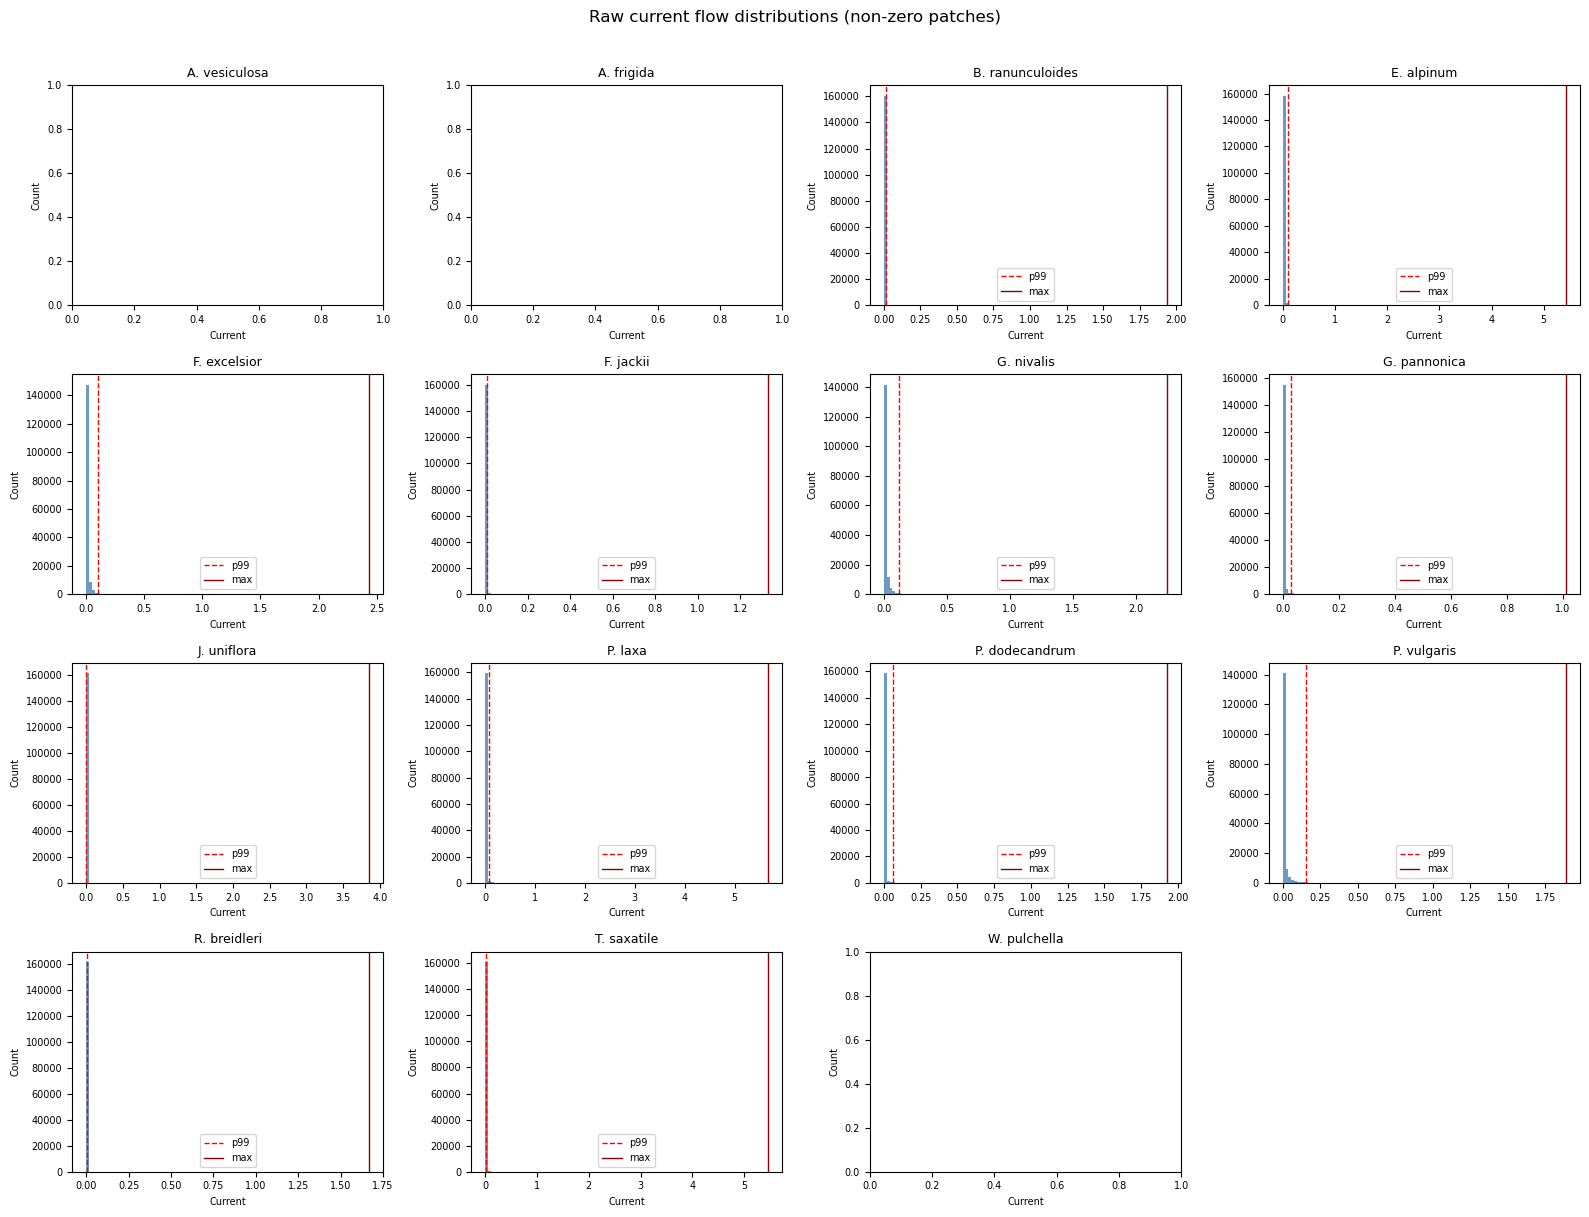

In [5]:
n_species = len(results)
n_cols = 4
n_rows = (n_species + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes_flat = axes.flatten()

for idx, (sp, data) in enumerate(results.items()):
    ax = axes_flat[idx]
    current = data['current']
    # Only plot non-zero values for visibility
    nonzero = current[current > 0]
    if len(nonzero) > 0:
        ax.hist(nonzero, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
        ax.axvline(np.percentile(nonzero, 99), color='red', linestyle='--', linewidth=1, label='p99')
        ax.axvline(nonzero.max(), color='darkred', linestyle='-', linewidth=1, label='max')
        ax.legend(fontsize=7)
    ax.set_title(sp.split(' ')[0][0] + '. ' + sp.split(' ')[1], fontsize=9)
    ax.set_xlabel('Current', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(labelsize=7)

# Hide empty axes
for idx in range(n_species, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Raw current flow distributions (non-zero patches)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Summary statistics

In [6]:
summary_rows = []
for sp, data in results.items():
    c = data['current']
    nonzero = c[c > 0]
    cat = threatened_df[threatened_df['species'] == sp]['iucn_category'].values[0]
    summary_rows.append({
        'species': sp,
        'iucn_category': cat,
        'n_obs_patches': data['n_patches'],
        'n_components': data['n_components'],
        'current_max': c.max(),
        'current_p99': np.percentile(nonzero, 99) if len(nonzero) > 0 else 0,
        'current_mean_nz': nonzero.mean() if len(nonzero) > 0 else 0,
        'n_patches_with_current': len(nonzero),
        'suit_mean': data['suitability'].mean(),
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

                species   iucn_category  n_obs_patches  n_components  current_max  current_p99  current_mean_nz  n_patches_with_current  suit_mean
  Aldrovanda vesiculosa      ENDANGERED             26             1     0.000000     0.000000         0.000000                       0   0.126297
       Andreaea frigida      VULNERABLE             48             0     0.000000     0.000000         0.000000                       0   0.339773
Baldellia ranunculoides NEAR_THREATENED             76             2     1.937600     0.012718         0.000818                  161425   0.082785
       Eryngium alpinum NEAR_THREATENED           1045            74     5.422329     0.098045         0.005634                  161851   0.079532
     Fraxinus excelsior NEAR_THREATENED           8674           459     2.436966     0.097944         0.009108                  162014   0.150887
       Frullania jackii      VULNERABLE             69             2     1.330664     0.011563         0.000684       

### Save results for notebook 32

Save raw (un-normalised) current flow arrays and suitability arrays
so that normalisation decisions can be made independently in the
gap analysis notebook.

In [7]:
import os

output_dir = 'gap_analysis_output'
os.makedirs(output_dir, exist_ok=True)

# Filter: only keep species with >= 2 components (otherwise current is all zeros)
valid_results = {sp: data for sp, data in results.items() if data['n_components'] >= 2}
invalid_species = [sp for sp, data in results.items() if data['n_components'] < 2]

if invalid_species:
    print(f'Excluding {len(invalid_species)} species with < 2 components (no connectivity to measure):')
    for sp in invalid_species:
        print(f'  {sp} ({results[sp]["n_components"]} components, {results[sp]["n_patches"]} obs patches)')
    print()

# Save current flows as .npz (keys = species names with underscores)
current_arrays = {sp.replace(' ', '_'): data['current'] for sp, data in valid_results.items()}
np.savez_compressed(f'{output_dir}/current_flows.npz', **current_arrays)

# Save species metadata (only valid species)
valid_summary = summary[summary['species'].isin(valid_results.keys())]
valid_summary.to_csv(f'{output_dir}/species_summary.csv', index=False)

print(f'Saved {len(current_arrays)} current flow arrays to {output_dir}/current_flows.npz')
print(f'Saved species summary to {output_dir}/species_summary.csv')
print(f'\nNote: suitability scores are already in gnn_training_output/suitability_scores.npz')

Excluding 3 species with < 2 components (no connectivity to measure):
  Aldrovanda vesiculosa (1 components, 26 obs patches)
  Andreaea frigida (0 components, 48 obs patches)
  Woodsia pulchella (0 components, 24 obs patches)

Saved 12 current flow arrays to gap_analysis_output/current_flows.npz
Saved species summary to gap_analysis_output/species_summary.csv

Note: suitability scores are already in gnn_training_output/suitability_scores.npz
